In [5]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import scanpy as sc
from starcat import starCAT
from scipy.stats import ttest_ind 
import cna
from multianndata import MultiAnnData
import harmonypy as hm


In [6]:
harm_vars = [ 'sample']

In [7]:
adata = sc.read('../../../Data/Revision/Melanoma_Clinical_GSE120575/GSE120575_melanoma_scRNA.Tcell.logTPM.clustered.h5ad')

Only considering the two last: ['.clustered', '.h5ad'].
Only considering the two last: ['.clustered', '.h5ad'].


In [8]:
adata

AnnData object with n_obs × n_vars = 12831 × 18938
    obs: 'cell_label', 'cell_id', 'sample', 'response', 'therapy', 'timepoint', 'patient', 'cell_id_orig', 'Cell Name', 'Cluster number', 'Cell Name Orig', 'CD8+CD39+TIM+_Sorted', 'CD8+CD39-TIM-_Sorted', 'Cluster label', 'n_counts', 'leiden', 'leiden_labeled', 'leiden_labeled_reduced', 'Supervised_T', 'Supervised_Memory_CD4', 'Supervised_Memory_CD8', 'Supervised_Activated', 'Supervised_Exhausted'
    var: 'gene_symbol', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'patient_colors', 'pca', 'rank_genes_groups', 'response_colors', 'timepoint_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [9]:
madata = MultiAnnData(adata)
madata.sampleid = 'sample'
samplem = madata.obs[['sample', 'response', 'therapy', 'timepoint', 'patient']].drop_duplicates().reset_index(drop = True)
samplem.index = samplem['sample']
madata.samplem = samplem

In [11]:
cna.tl.nam(madata, show_progress=True, force_recompute=True)

qcd NAM not found; computing and saving
	median kurtosis: 12.028980252297002
	20th percentile R2(t,t-1): nan
	median kurtosis: 8.35106521132483
	20th percentile R2(t,t-1): 0.7474447011947631
	median kurtosis: 5.836976114801942
	20th percentile R2(t,t-1): 0.9050216794013977
stopping after 3 steps
covariate-adjusted NAM not found; computing and saving
computing SVD


In [13]:
res = cna.tl.association(madata, madata.samplem['response']=='Non-responder')


/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/cna/tools/_association.py:79: UserWarning: global association p-value attained minimal possible value. Consider increasing Nnull
  warnings.warn('global association p-value attained minimal possible value. '+\


In [14]:
res.p

0.000999000999000999

In [32]:
madata.obs['ncorr'] = res.ncorrs
madata.obs[f'ncorr_thresh_fdr10p'] = res.ncorrs * (np.abs(madata.obs.ncorr) >= res.fdr_10p_t)
madata.obs[f'ncorr_thresh_fdr5p'] = res.ncorrs * (np.abs(madata.obs.ncorr) >= res.fdr_5p_t)

In [39]:
cnares = madata.obs[['ncorr']]
cnares[f'ncorr_thresh_fdr10p'] = res.ncorrs * (np.abs(madata.obs.ncorr) >= res.fdr_10p_t)
cnares[f'ncorr_thresh_fdr5p']  = res.ncorrs * (np.abs(madata.obs.ncorr) >= res.fdr_5p_t)
cnares.to_csv('../../../Data/Revision/Melanoma_Clinical_GSE120575/GSE120575_melanoma_scRNA.Tcell.logTPM.clustered.CNAanalysis.responsevsnonresponse.tsv', sep='\t')

/tmp/ipykernel_277553/520981176.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cnares[f'ncorr_thresh_fdr10p'] = res.ncorrs * (np.abs(madata.obs.ncorr) >= res.fdr_10p_t)
/tmp/ipykernel_277553/520981176.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cnares[f'ncorr_thresh_fdr5p']  = res.ncorrs * (np.abs(madata.obs.ncorr) >= res.fdr_5p_t)


In [31]:
res.fdrs

,threshold,fdr,num_detected
0,0.164842,0.426851,8030
1,0.166490,0.421572,7975
2,0.168138,0.416129,7924
3,0.169787,0.410447,7879
4,0.171435,0.404556,7837
...,...,...,...
295,0.651124,0.001000,3
296,0.652773,0.001000,3
297,0.654421,0.001500,2
298,0.656070,0.001000,2


In [21]:
res.ncorrs 

array([-0.35490885, -0.27460821, -0.12428652, ...,  0.40920187,
       -0.30377323, -0.40770183])

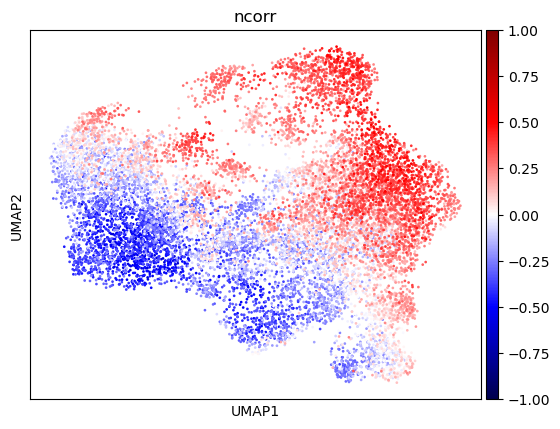

In [22]:
sc.pl.umap(madata, color='ncorr', cmap='seismic', vmin=-1, vmax=1, s=15)

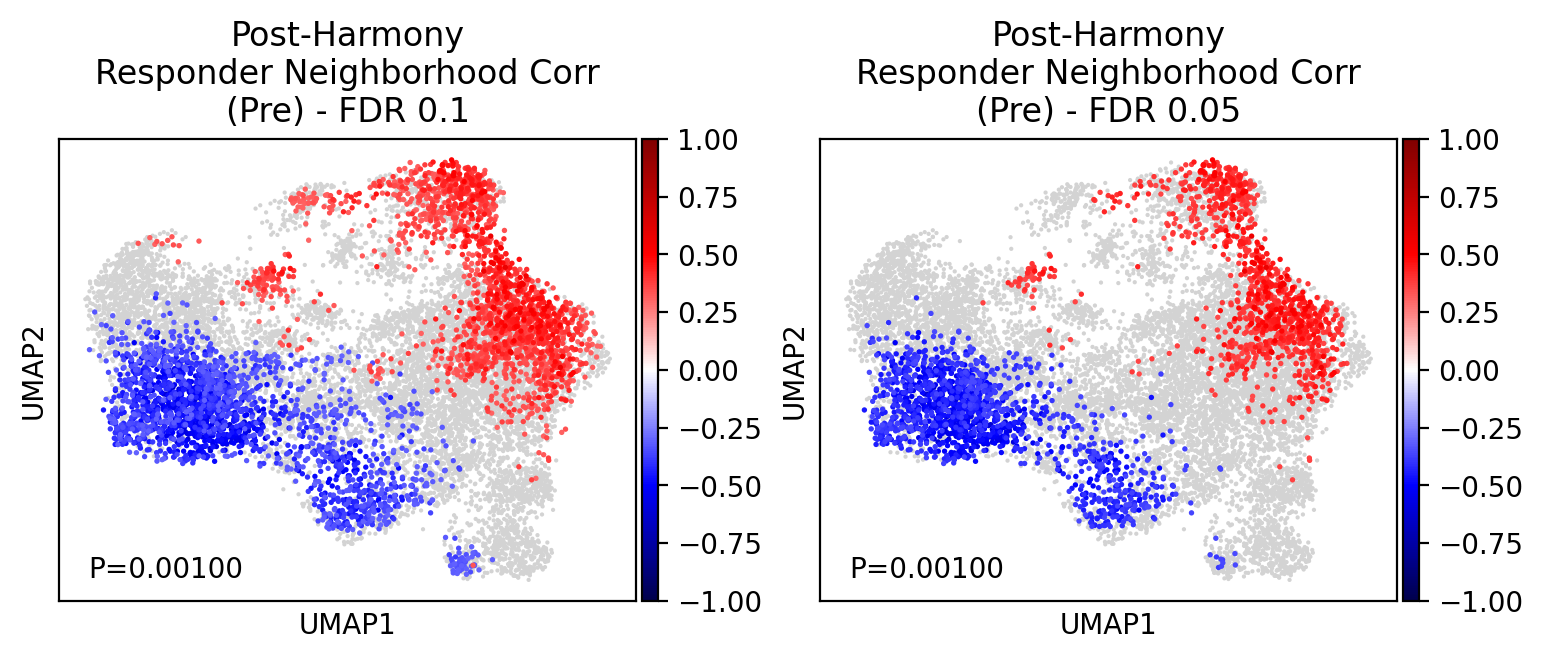

In [37]:
fig, axes = plt.subplots(dpi = 200, figsize = (9,3), ncols = 2)
ax = axes[0]
sc.pl.umap(madata, ax=ax, show=False)
sc.pl.umap(madata[madata.obs.ncorr_thresh_fdr10p != 0], color='ncorr', cmap='seismic', vmin=-1, vmax=1, s=15, 
           ax=ax, show=False,
          title =  'Post-Harmony\nResponder Neighborhood Corr\n(Pre) - FDR 0.1')
ax.text(.05, .05, f'P=%.5f' % (res.p), transform=ax.transAxes)

ax = axes[1]
sc.pl.umap(madata, ax=ax, show=False)
sc.pl.umap(madata[madata.obs.ncorr_thresh_fdr5p != 0], color='ncorr', cmap='seismic', vmin=-1, vmax=1, s=15, 
           ax=ax, show=False,
          title =  'Post-Harmony\nResponder Neighborhood Corr\n(Pre) - FDR 0.05')
ax.text(.05, .05, f'P=%.5f' % (res.p), transform=ax.transAxes)
plt.show()

In [4]:
adata_tpm = sc.read('../../../Data/Revision/Melanoma_Clinical_GSE120575/GSE120575_melanoma_scRNA.TPM.h5ad')

In [5]:
adata_tpm = adata_tpm[adata.obs.index, :]

In [6]:
adata_pre = adata[adata.obs['timepoint']=='Pre', :].copy()

In [7]:
sc.pp.pca(adata_pre)

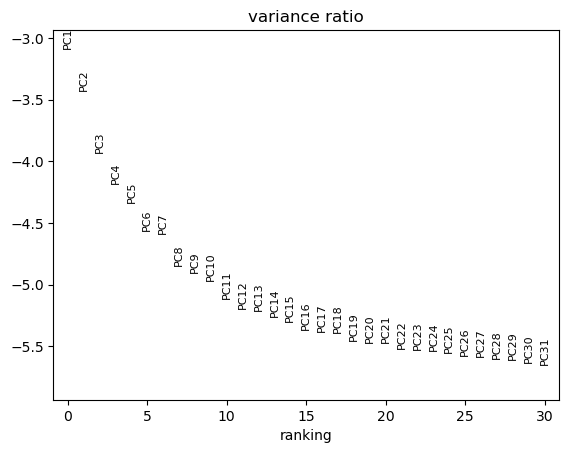

In [8]:
sc.pl.pca_variance_ratio(adata_pre, log='true')

In [9]:
ho = hm.run_harmony(adata_pre.obsm['X_pca'], adata_pre.obs, harm_vars, max_iter_harmony=50)

2024-09-30 09:12:54,922 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2024-09-30 09:12:56,468 - harmonypy - INFO - sklearn.KMeans initialization complete.
2024-09-30 09:12:56,539 - harmonypy - INFO - Iteration 1 of 50
2024-09-30 09:12:58,310 - harmonypy - INFO - Iteration 2 of 50
2024-09-30 09:12:59,935 - harmonypy - INFO - Iteration 3 of 50
2024-09-30 09:13:01,000 - harmonypy - INFO - Iteration 4 of 50
2024-09-30 09:13:01,873 - harmonypy - INFO - Iteration 5 of 50
2024-09-30 09:13:02,710 - harmonypy - INFO - Iteration 6 of 50
2024-09-30 09:13:03,623 - harmonypy - INFO - Iteration 7 of 50
2024-09-30 09:13:04,238 - harmonypy - INFO - Iteration 8 of 50
2024-09-30 09:13:04,861 - harmonypy - INFO - Iteration 9 of 50
2024-09-30 09:13:05,397 - harmonypy - INFO - Iteration 10 of 50
2024-09-30 09:13:06,064 - harmonypy - INFO - Iteration 11 of 50
2024-09-30 09:13:06,617 - harmonypy - INFO - Iteration 12 of 50
2024-09-30 09:13:07,229 - harmonypy - INFO - Iteration 13 of

In [10]:
#adata_pre.obsm['X_pca_harmony'] = ho.Z_corr.T
adata_pre.obsm['X_pca'] = ho.Z_corr.T

In [11]:
#sc.pp.neighbors(adata_pre, use_rep='X_pca_harmony')
sc.pp.neighbors(adata_pre, use_rep='X_pca')

In [12]:
sc.tl.umap(adata_pre)

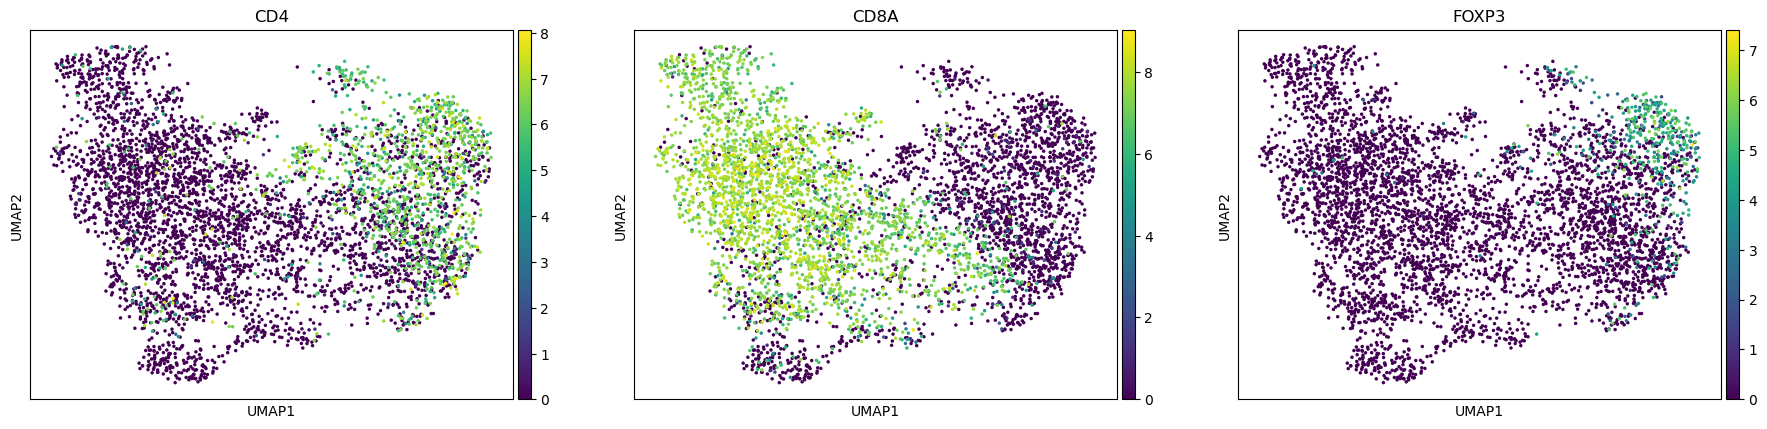

In [13]:
sc.pl.umap(adata_pre, color=['CD4', 'CD8A', 'FOXP3'])

In [14]:
madata = MultiAnnData(adata_pre)
madata.sampleid = 'sample'
samplem = madata.obs[['sample', 'response', 'therapy', 'timepoint', 'patient']].drop_duplicates().reset_index(drop = True)
samplem.index = samplem['sample']
madata.samplem = samplem

In [30]:
samplem

,sample,response,therapy,timepoint,patient
sample,,,,,
Pre_P1,Pre_P1,Responder,anti-CTLA4,Pre,P1
Pre_P2,Pre_P2,Non-responder,anti-PD1,Pre,P2
Pre_P3,Pre_P3,Non-responder,anti-PD1,Pre,P3
Pre_P4,Pre_P4,Non-responder,anti-CTLA4+PD1,Pre,P4
Pre_P6,Pre_P6,Non-responder,anti-CTLA4,Pre,P6
Pre_P7,Pre_P7,Responder,anti-CTLA4+PD1,Pre,P7
Pre_P8,Pre_P8,Responder,anti-CTLA4+PD1,Pre,P8
Pre_P12,Pre_P12,Non-responder,anti-PD1,Pre,P12
Pre_P15,Pre_P15,Non-responder,anti-PD1,Pre,P15


In [16]:
cna.tl.nam(madata, show_progress=True, force_recompute=True)

qcd NAM not found; computing and saving
	median kurtosis: 5.712146034143388
	20th percentile R2(t,t-1): nan
	median kurtosis: 4.01971147015741
	20th percentile R2(t,t-1): 0.7799698233604431
	median kurtosis: 3.1553999774129236
	20th percentile R2(t,t-1): 0.9323355197906494
stopping after 3 steps
covariate-adjusted NAM not found; computing and saving
computing SVD


In [17]:
res = cna.tl.association(madata, madata.samplem['therapy']=='anti-CTLA4')
print(res.p)
res = cna.tl.association(madata, madata.samplem['therapy']=='anti-PD1')
print(res.p)
res = cna.tl.association(madata, madata.samplem['therapy']=='anti-CTLA4+PD1')
print(res.p)

/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/cna/tools/_association.py:61: UserWarning: data supported use of 3 NAM PCs, which is the maximum considered. Consider allowing more PCs by using the "ks" argument.
  warnings.warn(('data supported use of {} NAM PCs, which is the maximum considered. '+\


0.25574425574425574
0.18181818181818182
0.10989010989010989


In [18]:
res = cna.tl.association(madata, madata.samplem['response']=='Responder', Nnull=100000)
res.p

0.0003999960000399996

In [20]:
madata.obs['ncorr'] = res.ncorrs
madata.obs[f'ncorr_thresh_fdr10p'] = res.ncorrs * (np.abs(madata.obs.ncorr) >= res.fdr_10p_t)
madata.obs[f'ncorr_thresh_fdr5p'] = res.ncorrs * (np.abs(madata.obs.ncorr) >= res.fdr_5p_t)

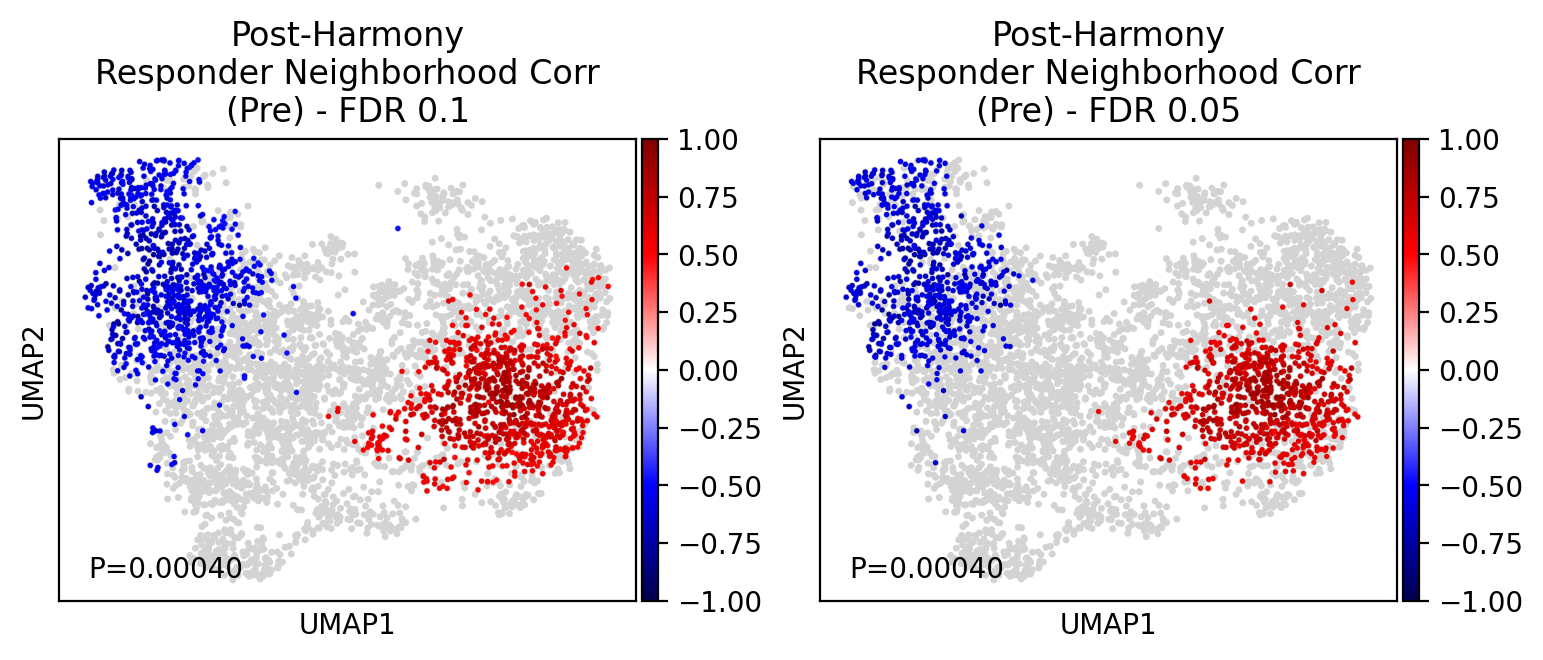

In [23]:
fig, axes = plt.subplots(dpi = 200, figsize = (9,3), ncols = 2)
ax = axes[0]
sc.pl.umap(madata, ax=ax, show=False)
sc.pl.umap(madata[madata.obs.ncorr_thresh_fdr10p != 0], color='ncorr', cmap='seismic', vmin=-1, vmax=1, s=15, 
           ax=ax, show=False,
          title =  'Post-Harmony\nResponder Neighborhood Corr\n(Pre) - FDR 0.1')
ax.text(.05, .05, f'P=%.5f' % (res.p), transform=ax.transAxes)

ax = axes[1]
sc.pl.umap(madata, ax=ax, show=False)
sc.pl.umap(madata[madata.obs.ncorr_thresh_fdr5p != 0], color='ncorr', cmap='seismic', vmin=-1, vmax=1, s=15, 
           ax=ax, show=False,
          title =  'Post-Harmony\nResponder Neighborhood Corr\n(Pre) - FDR 0.05')
ax.text(.05, .05, f'P=%.5f' % (res.p), transform=ax.transAxes)
plt.show()

In [24]:
tcat = starCAT(reference='TCAT.V1', cachedir='../../../Data/Revision/Melanoma_Clinical_GSE120575/tcat_cache')

Using reference from starCAT database
Loading reference from existing cache file for reference TCAT.V1


In [25]:
usage, scores = tcat.fit_transform(adata_tpm)

/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/starcat/starcat.py:249: UserWarning: WARNING!: query input is not an integer count matrix as expected.
            Please provide an integer count matrix unless you are sure you know what you are doing.
  warnings.warn("""WARNING!: query input is not an integer count matrix as expected.


3403 out of 3412 genes in the reference overlap with the query


/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.0.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [26]:
usage_pre = usage.loc[adata_pre.obs.index, :]
scores_pre = scores.loc[adata_pre.obs.index, :]

In [29]:
usage_pre.corrwith(madata.obs.loc[usage_pre.index, 'ncorr']).sort_values()

Exhaustion            -0.536424
TIMD4/TIM3            -0.487649
HLA                   -0.433773
CD8-EM                -0.293366
CD8-Trm               -0.286759
CellCycle-S           -0.264552
Multi-Cytokine        -0.237663
CellCycle-Late-S      -0.227038
TEMRA                 -0.198903
Tph                   -0.198769
ISG                   -0.197802
CellCycle-G2M         -0.185753
ICOS/CD38             -0.183689
NME1/FABP5            -0.167157
Cytoskeleton          -0.146766
Cytotoxic             -0.141396
IL10/IL19             -0.138514
Metallothionein       -0.098901
OX40/EBI3             -0.069273
gdT                   -0.068779
Heatshock             -0.066458
Doublet-RBC           -0.011012
Tfh-2                 -0.002719
IEG2                   0.016795
SOX4/TOX2              0.019072
Th17-Activated         0.021330
Doublet-Myeloid        0.031542
Doublet-Platelet       0.032138
Doublet-Bcell          0.042397
Th2-Activated          0.045641
Doublet-Plasmablast    0.045971
CTLA4/CD

Text(0.5, 1.0, 'Correlation with\nNeighborhood Coefficient')

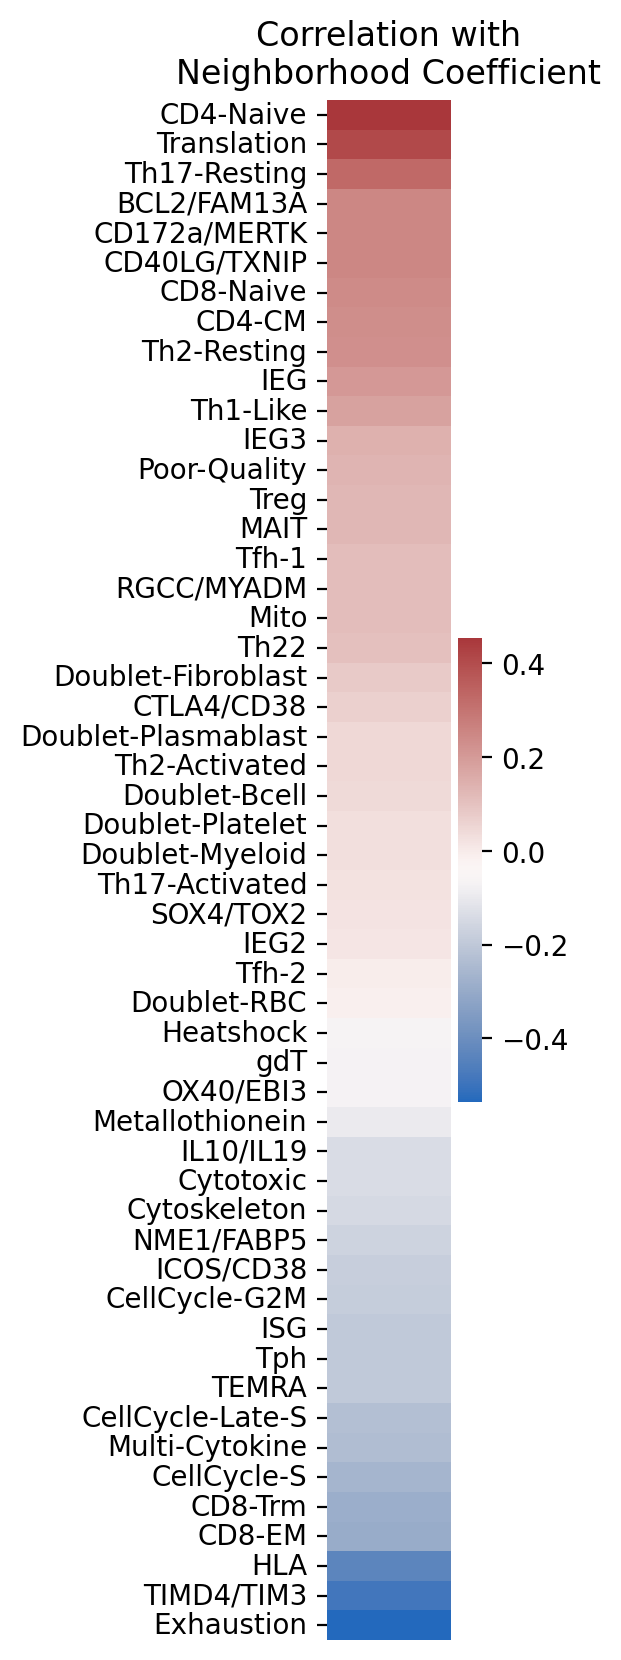

In [31]:
fig, ax = plt.subplots(dpi = 200, figsize = (1, 10))
sns.heatmap(pd.DataFrame(usage_pre.corrwith(madata.obs.loc[usage_pre.index, 'ncorr']).sort_values(ascending = False)), 
            cmap = 'vlag')
ax.set_xticks([])
ax.set_title('Correlation with\nNeighborhood Coefficient')

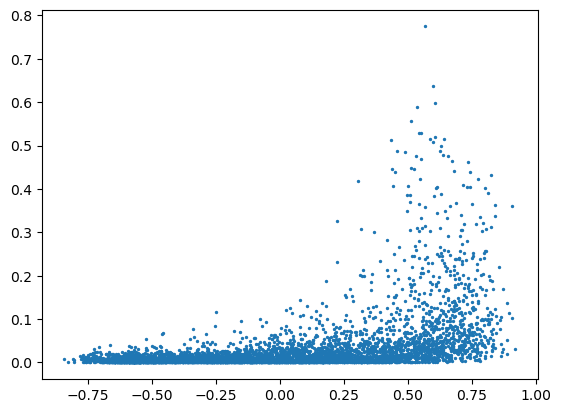

In [41]:
plt.scatter(madata.obs.loc[usage_pre.index, 'ncorr'], usage_pre.loc[:, 'CD4-Naive'], s=2)

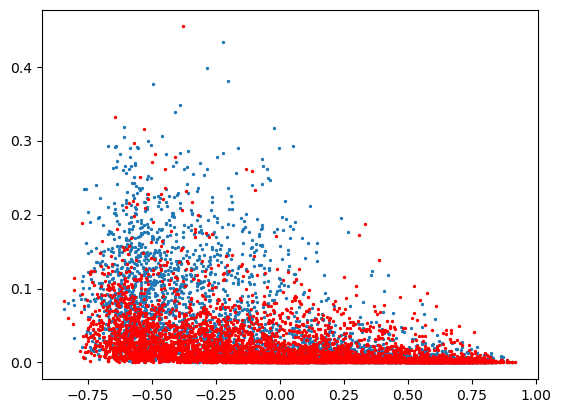

In [46]:
plt.scatter(madata.obs.loc[usage_pre.index, 'ncorr'], usage_pre.loc[:, 'Exhaustion'], s=2)
plt.scatter(madata.obs.loc[usage_pre.index, 'ncorr'], usage_pre.loc[:, 'HLA'], s=2, color='r')

In [50]:
madata.obs['Exhaustion'] = usage_pre.loc[madata.obs.index, 'Exhaustion']
madata.obs['CD4-Naive'] = usage_pre.loc[madata.obs.index, 'CD4-Naive']

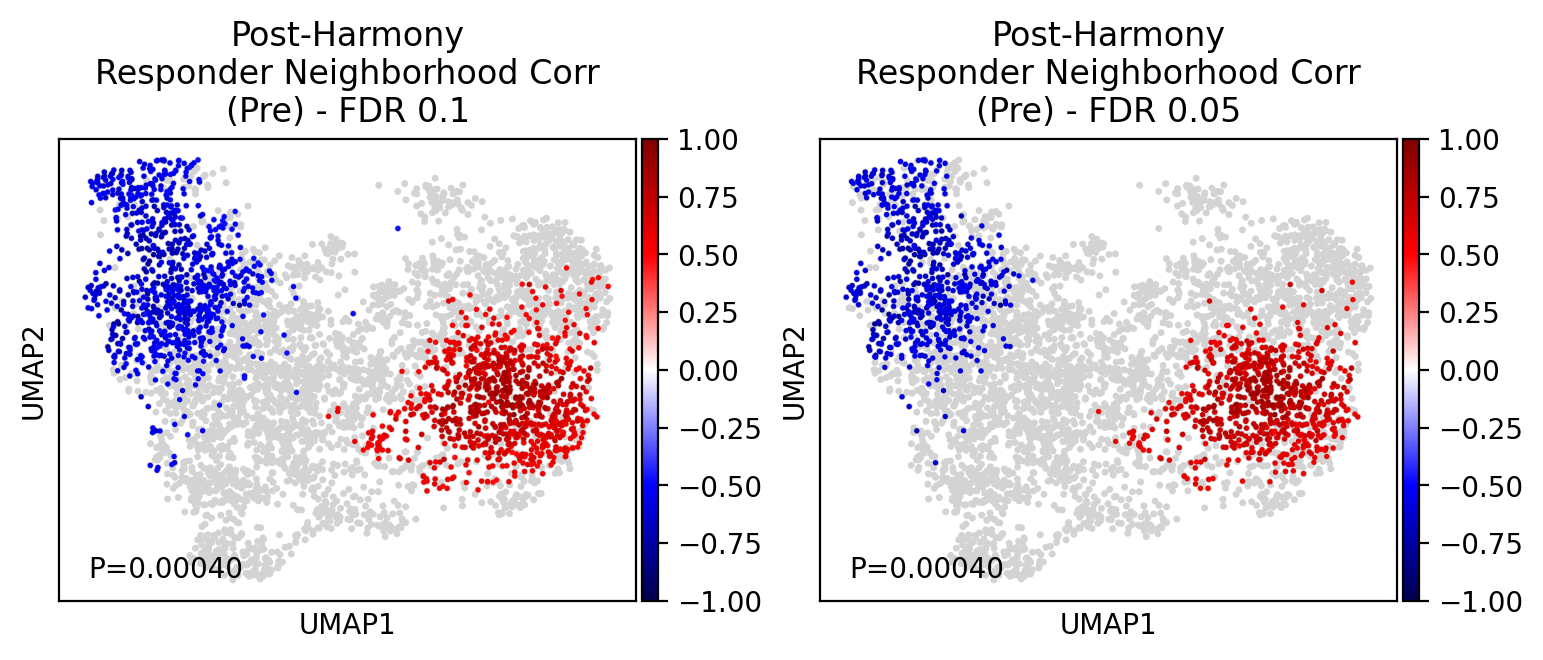

In [51]:
fig, axes = plt.subplots(dpi = 200, figsize = (9,3), ncols = 2)
ax = axes[0]
sc.pl.umap(madata, ax=ax, show=False)
sc.pl.umap(madata[madata.obs.ncorr_thresh_fdr10p != 0], color='ncorr', cmap='seismic', vmin=-1, vmax=1, s=15, 
           ax=ax, show=False,
          title =  'Post-Harmony\nResponder Neighborhood Corr\n(Pre) - FDR 0.1')
ax.text(.05, .05, f'P=%.5f' % (res.p), transform=ax.transAxes)

ax = axes[1]
sc.pl.umap(madata, ax=ax, show=False)
sc.pl.umap(madata[madata.obs.ncorr_thresh_fdr5p != 0], color='ncorr', cmap='seismic', vmin=-1, vmax=1, s=15, 
           ax=ax, show=False,
          title =  'Post-Harmony\nResponder Neighborhood Corr\n(Pre) - FDR 0.05')
ax.text(.05, .05, f'P=%.5f' % (res.p), transform=ax.transAxes)
plt.show()

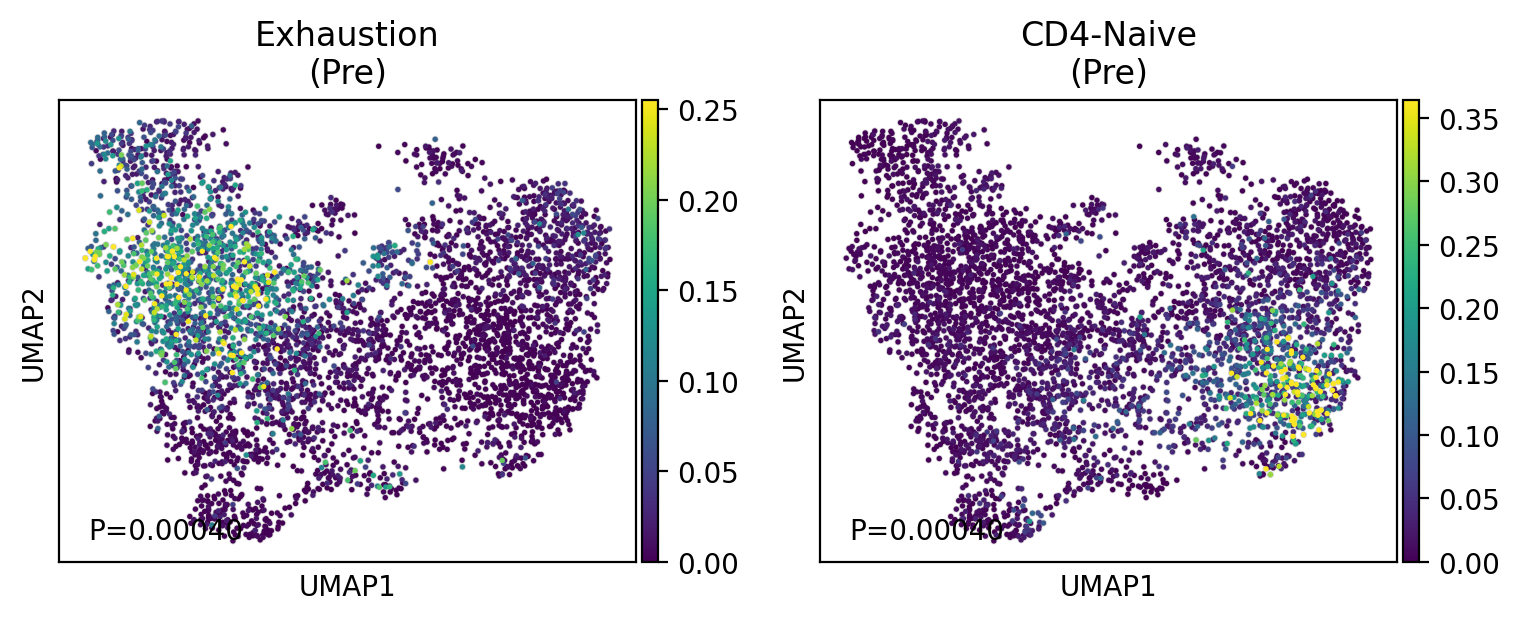

In [60]:
fig, axes = plt.subplots(dpi = 200, figsize = (9,3), ncols = 2)
ax = axes[0]
sc.pl.umap(madata, ax=ax, show=False)
sc.pl.umap(madata, color='Exhaustion',  vmin=-0, vmax='p99', s=15, 
           ax=ax, show=False,
          title =  'Exhaustion\n(Pre)')
ax.text(.05, .05, f'P=%.5f' % (res.p), transform=ax.transAxes)

ax = axes[1]
sc.pl.umap(madata, ax=ax, show=False)
sc.pl.umap(madata, color='CD4-Naive', vmin=0, vmax='p99', s=15, 
           ax=ax, show=False,
          title =  'CD4-Naive\n(Pre)')
ax.text(.05, .05, f'P=%.5f' % (res.p), transform=ax.transAxes)
plt.show()

In [64]:
madata.obs

,cell_label,cell_id,sample,response,therapy,timepoint,patient,n_counts,leiden,ncorr,ncorr_thresh_fdr10p,ncorr_thresh_fdr5p,Exhaustion,CD4-Naive
cell_id,,,,,,,,,,,,,,
A10_P3_M11,Sample 1,A10_P3_M11,Pre_P1,Responder,anti-CTLA4,Pre,P1,916771.762711,8,0.230521,0.000000,0.000000,0.004923,0.010122
A11_P1_M11,Sample 2,A11_P1_M11,Pre_P1,Responder,anti-CTLA4,Pre,P1,941175.610411,11,0.453108,0.000000,0.000000,0.033297,0.009082
A11_P3_M11,Sample 3,A11_P3_M11,Pre_P1,Responder,anti-CTLA4,Pre,P1,908999.212168,11,0.352242,0.000000,0.000000,0.003720,0.005104
A11_P4_M11,Sample 4,A11_P4_M11,Pre_P1,Responder,anti-CTLA4,Pre,P1,928806.196974,0,0.194619,0.000000,0.000000,0.048161,0.000422
A12_P3_M11,Sample 5,A12_P3_M11,Pre_P1,Responder,anti-CTLA4,Pre,P1,855798.949784,15,0.497244,0.497244,0.000000,0.002536,0.004600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H6_P3_M41_L001,Sample 15293,H6_P3_M41_L001,Pre_P35,Responder,anti-PD1,Pre,P35,876450.109315,2,0.346846,0.000000,0.000000,0.011759,0.000344
H7_P1_M41_L001,Sample 15294,H7_P1_M41_L001,Pre_P35,Responder,anti-PD1,Pre,P35,904694.927156,9,0.641039,0.641039,0.641039,0.000783,0.515491
H7_P3_M41_L001,Sample 15295,H7_P3_M41_L001,Pre_P35,Responder,anti-PD1,Pre,P35,860980.858950,4,0.346374,0.000000,0.000000,0.030584,0.026018


In [32]:
ind_high = madata.obs[madata.obs['ncorr_thresh_fdr5p']>0].index
high_means = usage_pre.loc[ind_high, :].groupby(madata.obs.loc[ind_high, 'sample']).mean()

ind_low = madata.obs[madata.obs['ncorr_thresh_fdr5p']<0].index
low_means = usage_pre.loc[ind_low, :].groupby(madata.obs.loc[ind_low, 'sample']).mean()

In [33]:
high_means

,CellCycle-G2M,Translation,HLA,ISG,Mito,Doublet-RBC,gdT,CellCycle-S,Cytotoxic,Doublet-Platelet,...,Tfh-2,OX40/EBI3,CD172a/MERTK,IEG3,Doublet-Fibroblast,SOX4/TOX2,CD40LG/TXNIP,Tph,Exhaustion,Tfh-1
sample,,,,,,,,,,,,,,,,,,,,,
Pre_P1,0.001324,0.007239,0.002715,0.012175,0.024302,0.001093,0.010710,0.002757,0.010816,0.003295,...,0.011544,0.012889,0.006267,0.088451,0.004527,0.006142,0.027141,0.004864,0.002012,0.002676
Pre_P2,0.001605,0.123362,0.011358,0.009020,0.010661,0.000689,0.005360,0.002592,0.010823,0.002287,...,0.012574,0.008458,0.046842,0.019701,0.003535,0.004504,0.126732,0.007941,0.005301,0.002753
Pre_P3,0.000579,0.256668,0.001048,0.006284,0.036110,0.000732,0.003076,0.005895,0.006184,0.002546,...,0.008751,0.001690,0.025294,0.017148,0.008732,0.006681,0.018737,0.000559,0.000394,0.009268
Pre_P4,0.001369,0.141975,0.001099,0.017358,0.025920,0.000850,0.007112,0.001408,0.010991,0.002184,...,0.003874,0.002750,0.022699,0.027541,0.003492,0.001681,0.078390,0.002667,0.001836,0.006287
Pre_P6,0.000070,0.229967,0.002353,0.000746,0.082022,0.001058,0.004373,0.117180,0.024464,0.002088,...,0.002342,0.001785,0.023379,0.010114,0.003436,0.002049,0.014280,0.000576,0.000986,0.002144
Pre_P7,0.000486,0.226962,0.001075,0.008807,0.009435,0.000776,0.005034,0.002018,0.003532,0.002028,...,0.014828,0.003873,0.035593,0.037423,0.003656,0.005474,0.061191,0.001836,0.001722,0.012465
Pre_P8,0.000725,0.227442,0.002442,0.004259,0.038170,0.000748,0.005053,0.002542,0.007007,0.002034,...,0.004079,0.001533,0.042244,0.003935,0.005025,0.010021,0.020251,0.000349,0.000638,0.010395
Pre_P12,0.001387,0.088029,0.002576,0.019548,0.001890,0.005688,0.007868,0.006407,0.008048,0.004203,...,0.009597,0.005730,0.021706,0.014375,0.024401,0.003373,0.076088,0.012051,0.007320,0.005637
Pre_P15,0.001288,0.120200,0.010874,0.005133,0.003192,0.000887,0.021119,0.002144,0.013550,0.002608,...,0.020695,0.028017,0.019551,0.080780,0.004151,0.003540,0.043392,0.010414,0.006552,0.012758


In [34]:
from scipy.stats import ttest_rel

In [35]:
res_t = pd.DataFrame(index = usage.columns, columns = ['t', 'pval'])

In [36]:
for g in usage.columns:
    a = high_means[g].dropna()
    b = low_means[g].dropna()
    overlap = sorted(set(a.index).intersection(b.index))

    t, p = ttest_rel(a[overlap], b[overlap])
    res_t.loc[g, 't'] = t
    res_t.loc[g, 'pval'] = p

In [37]:
res_t.sort_values('pval')

,t,pval
HLA,-10.328449,0.0
TIMD4/TIM3,-10.283761,0.0
CD172a/MERTK,8.789906,0.0
Exhaustion,-8.477187,0.0
BCL2/FAM13A,7.568292,0.000001
Translation,7.562517,0.000001
Multi-Cytokine,-7.494355,0.000001
TEMRA,-7.469907,0.000001
CD8-EM,-7.048435,0.000003
Th17-Resting,6.824418,0.000004


In [356]:
res_t[res_t['t']<0].sort_values(['pval', 't'])

,t,pval
Exhaustion,-14.359219,0.0
TIMD4/TIM3,-13.693931,0.0
HLA,-11.851494,0.0
Cytoskeleton,-8.787398,0.0
CD8-EM,-8.478685,0.0
Multi-Cytokine,-7.860291,0.0
CellCycle-Late-S,-7.617568,0.0
CellCycle-S,-7.524399,0.0
CellCycle-G2M,-7.516085,0.0
ICOS/CD38,-6.954903,0.0


In [357]:
res_t[res_t['t']>0].sort_values(['pval', 't'])

,t,pval
CD40LG/TXNIP,9.035749,0.0
Th17-Resting,8.673718,0.0
Translation,8.207291,0.0
CD4-CM,7.090915,0.0
CD4-Naive,6.992532,0.0
BCL2/FAM13A,6.915899,0.0
Mito,6.834275,0.0
Th1-Like,6.821283,0.0
IEG,6.507988,0.0
Th2-Resting,5.978374,0.0


/tmp/ipykernel_63577/1060166611.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['R', 'NR'])
/tmp/ipykernel_63577/1060166611.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['R', 'NR'])
/tmp/ipykernel_63577/1060166611.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['R', 'NR'])
/tmp/ipykernel_63577/1060166611.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['R', 'NR'])
/tmp/ipykernel_63577/1060166611.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['R', 'NR'])


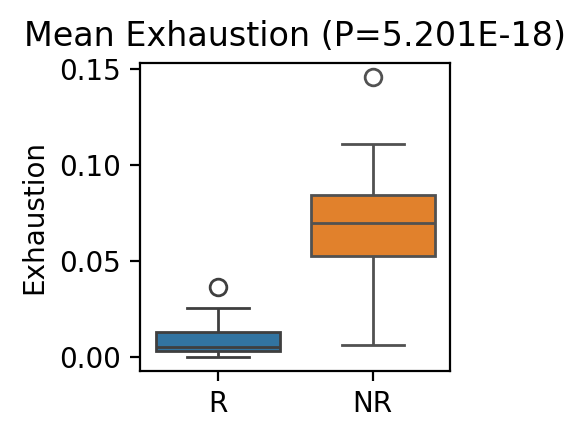

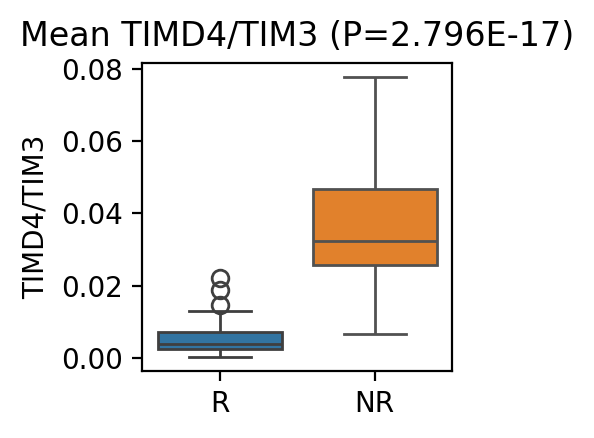

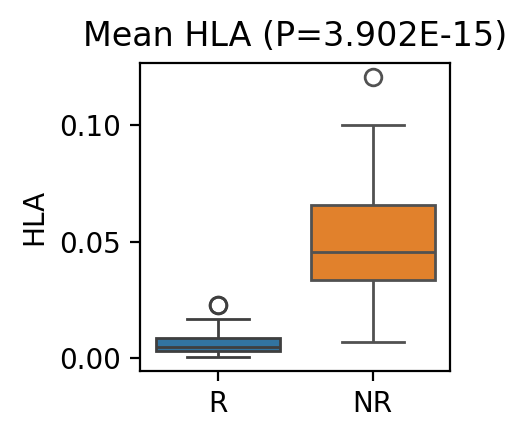

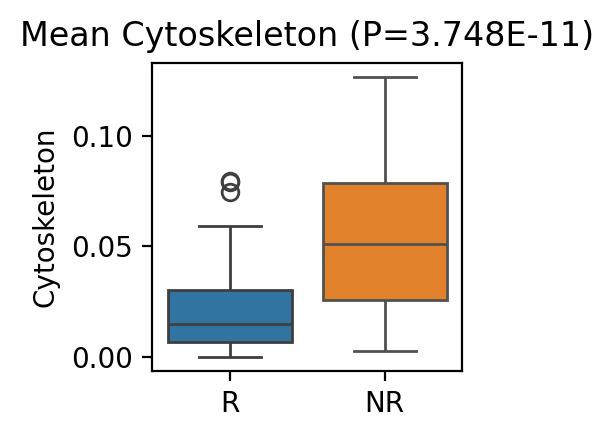

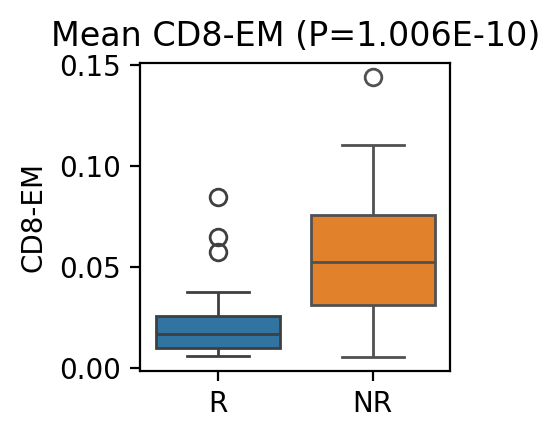

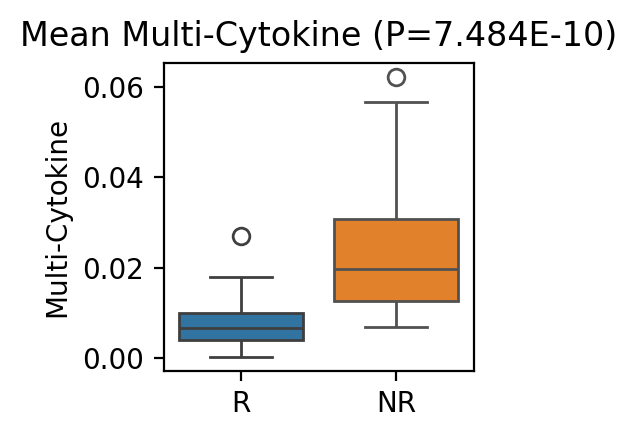

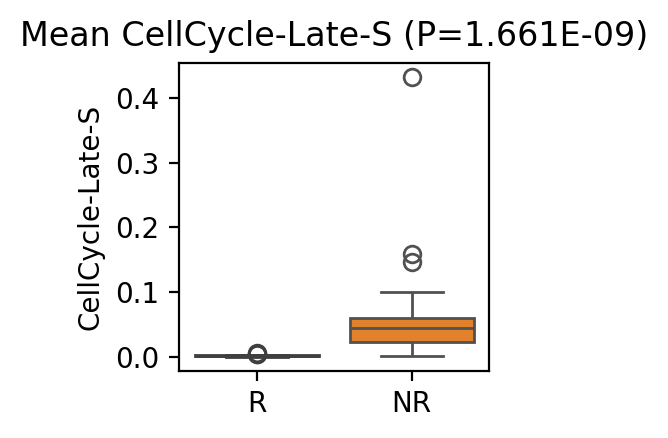

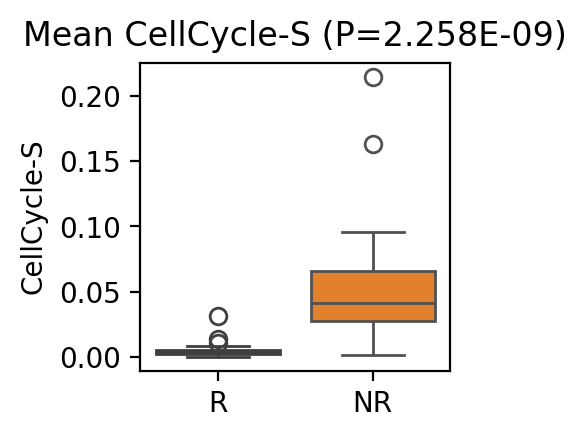

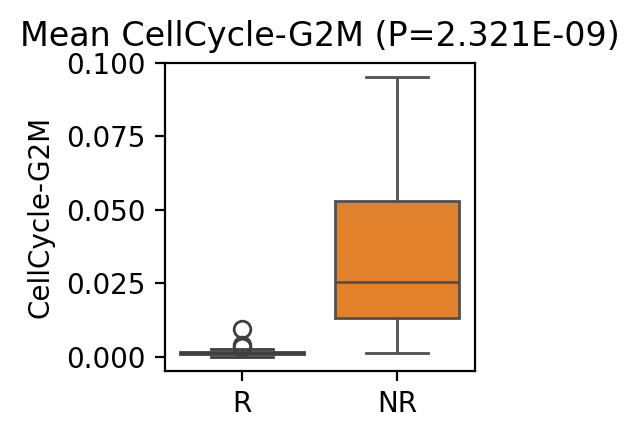

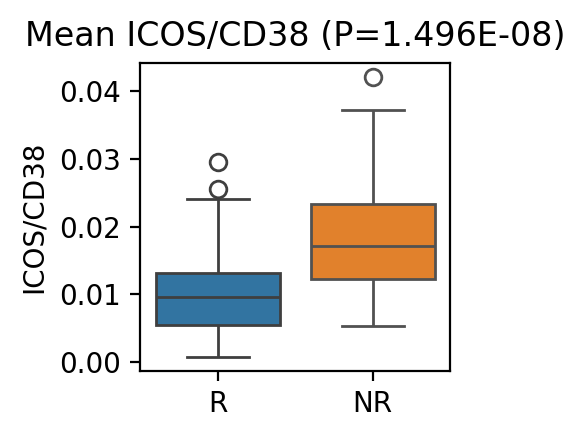

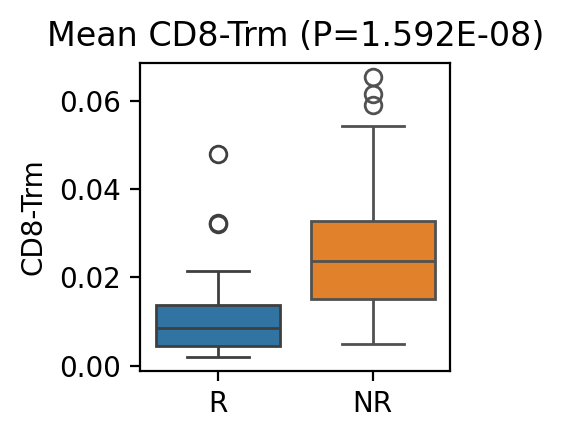

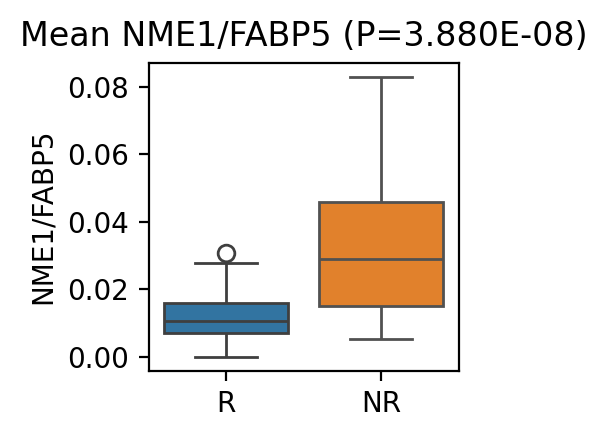

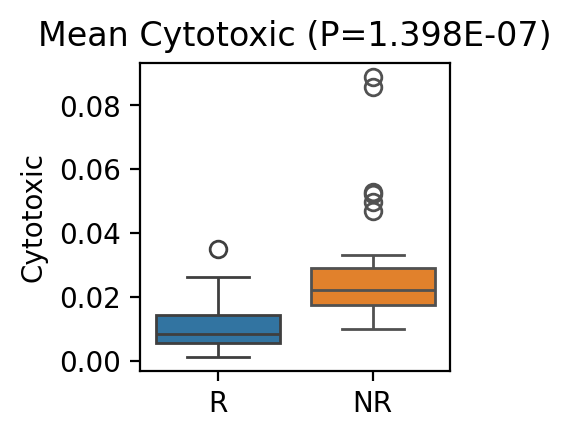

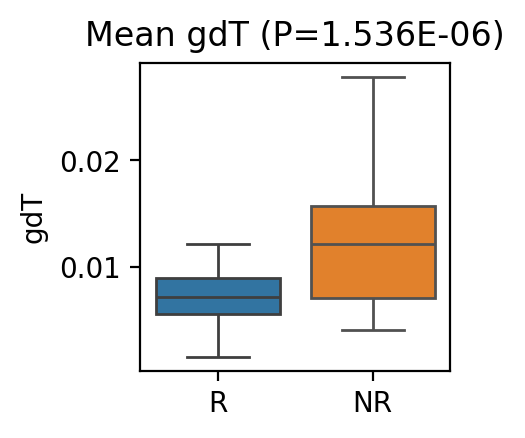

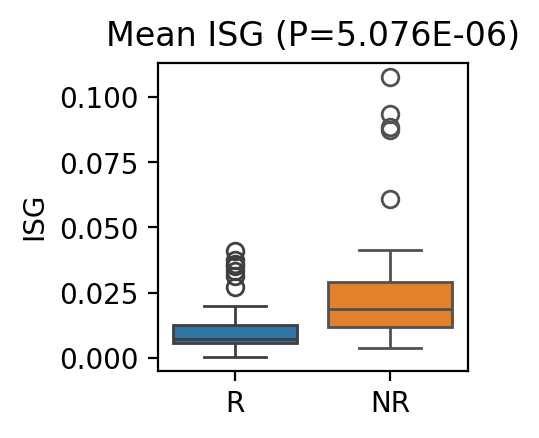

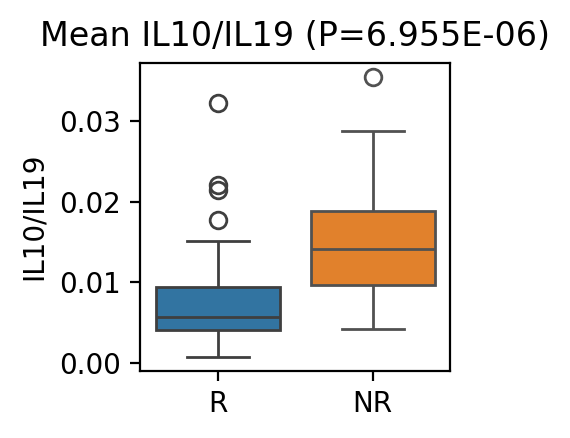

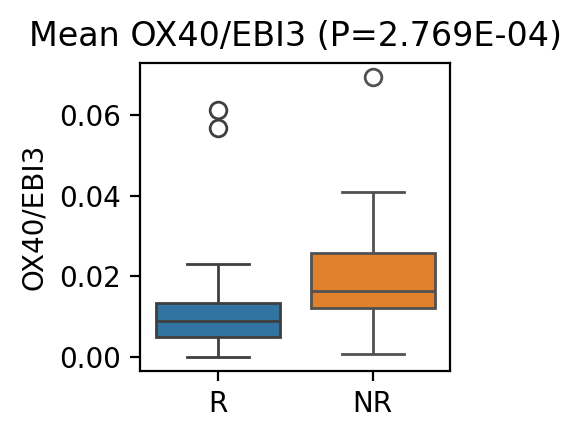

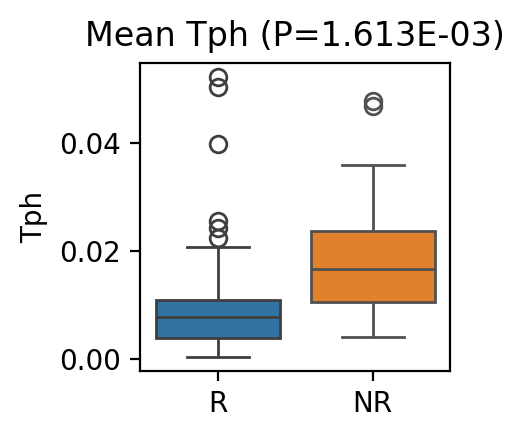

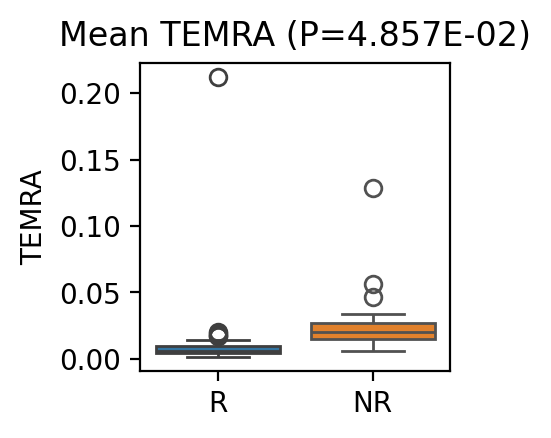

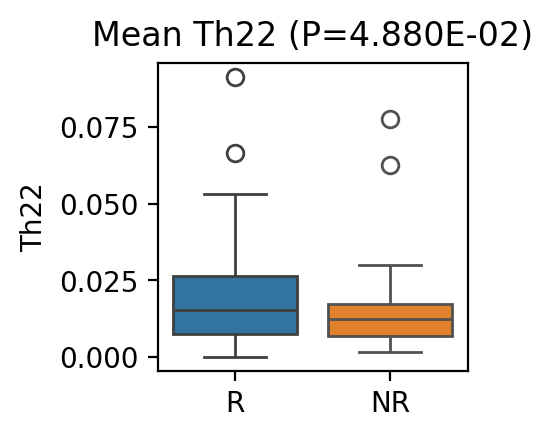

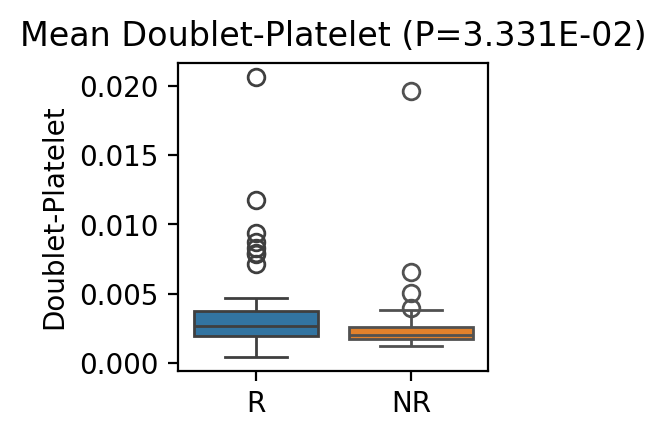

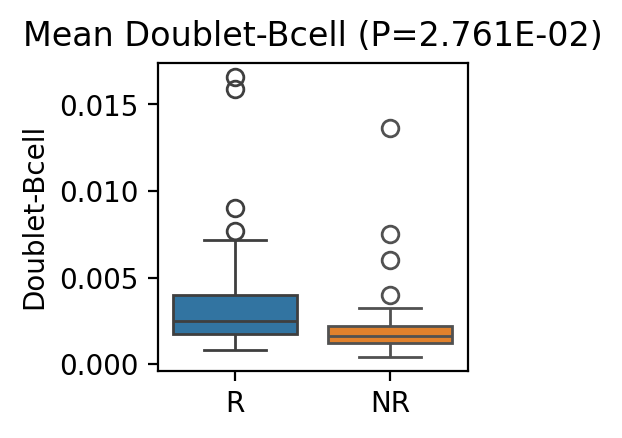

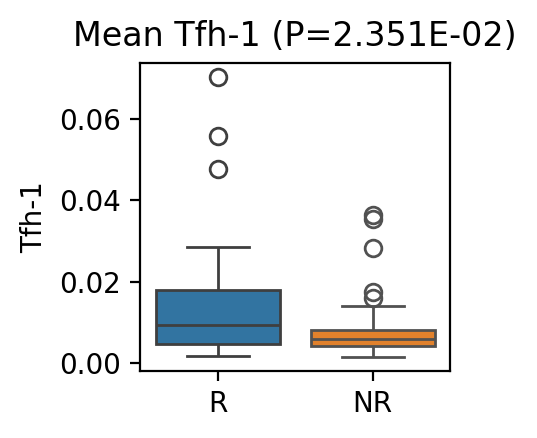

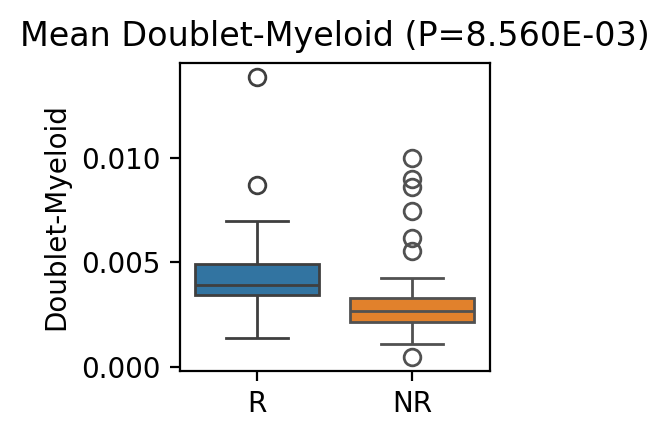

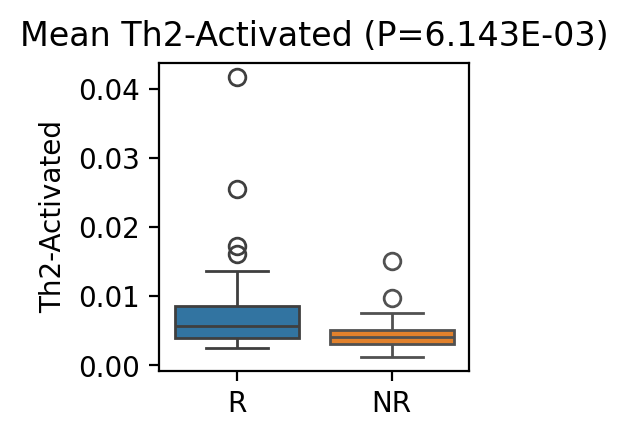

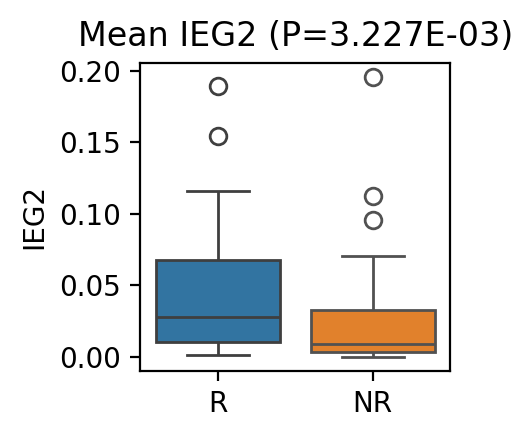

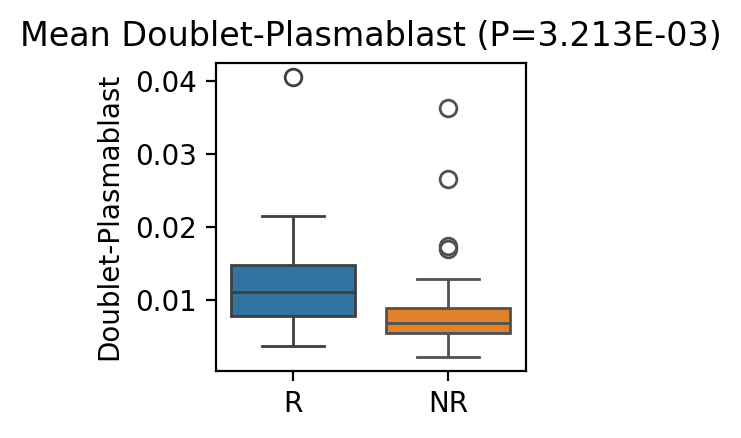

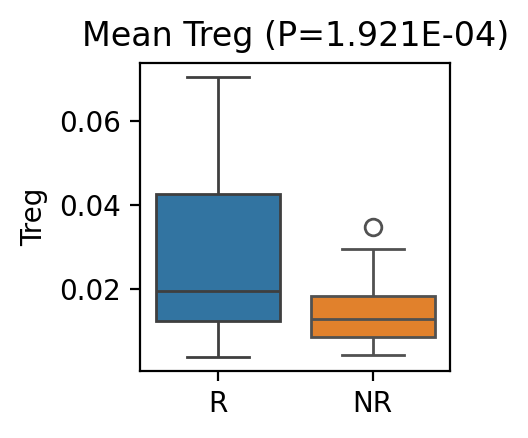

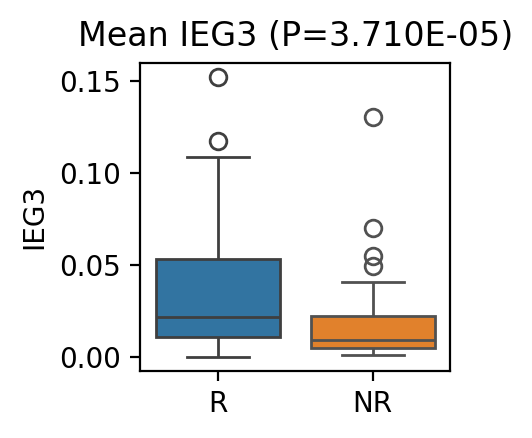

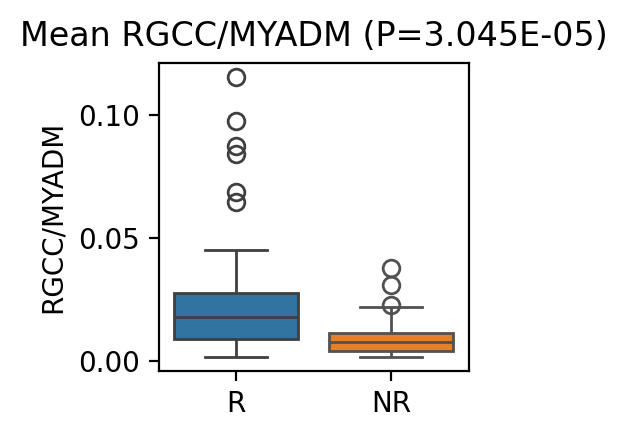

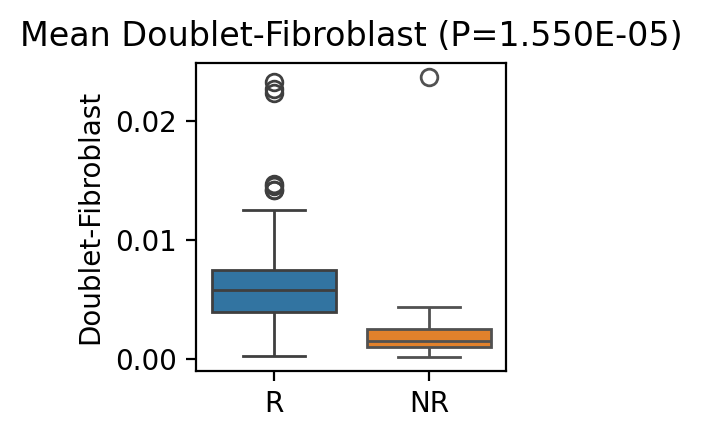

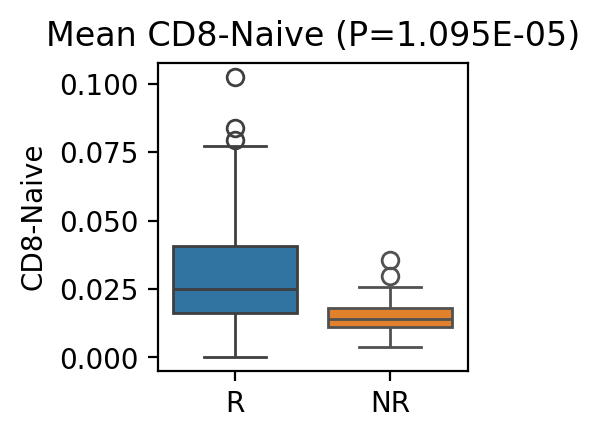

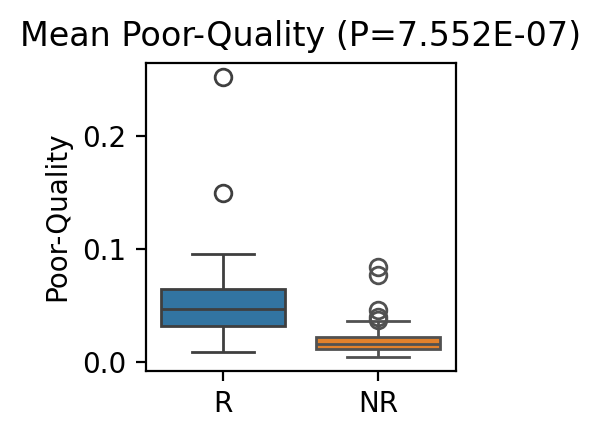

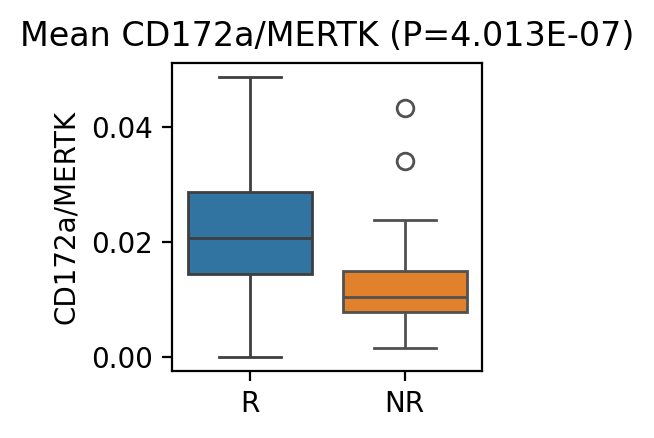

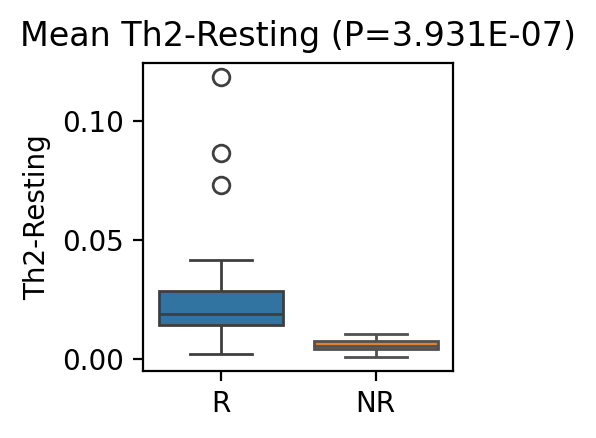

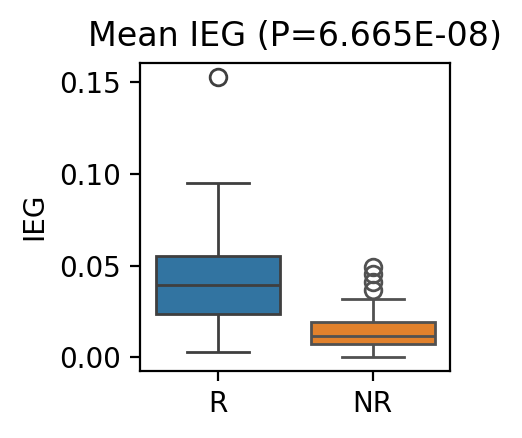

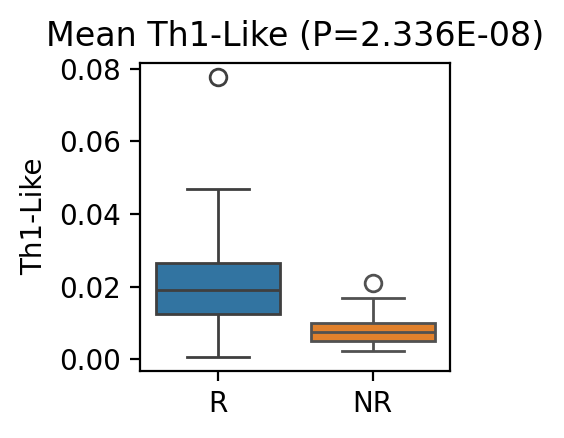

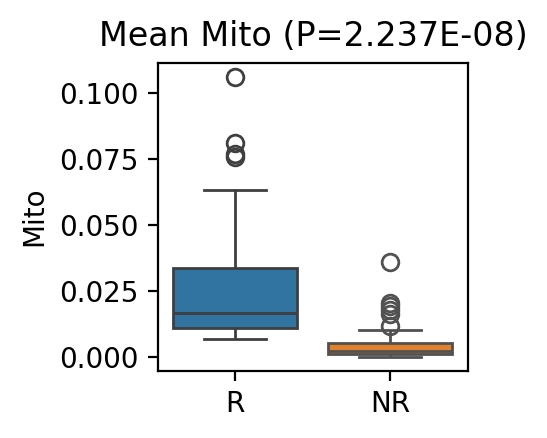

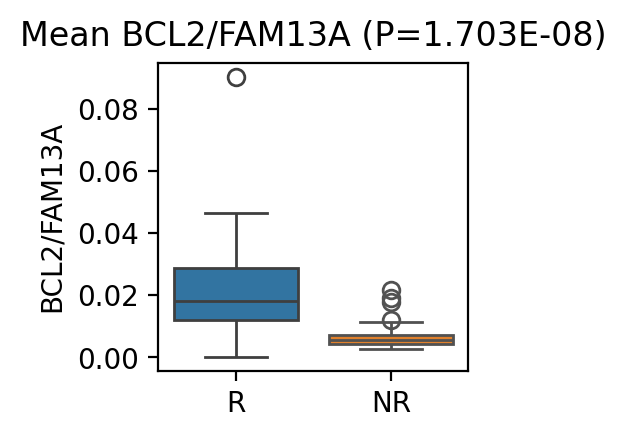

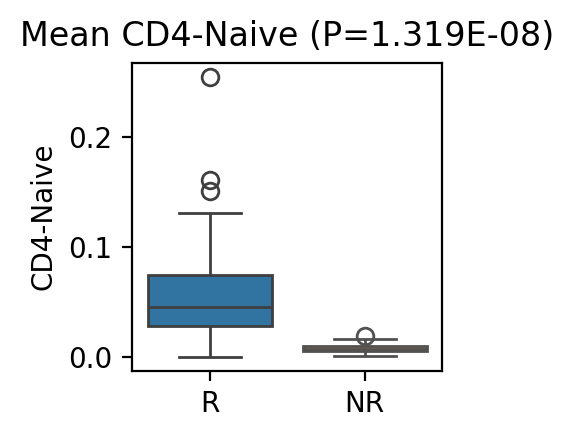

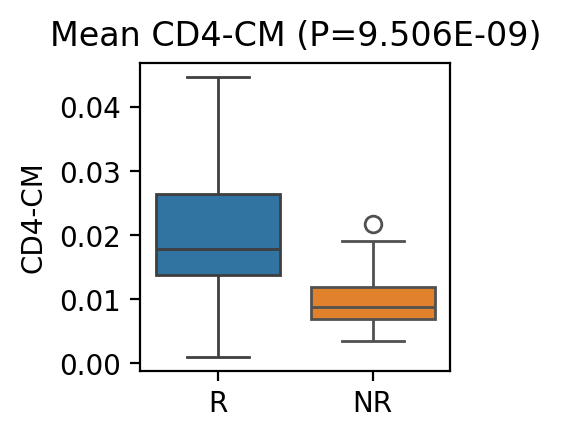

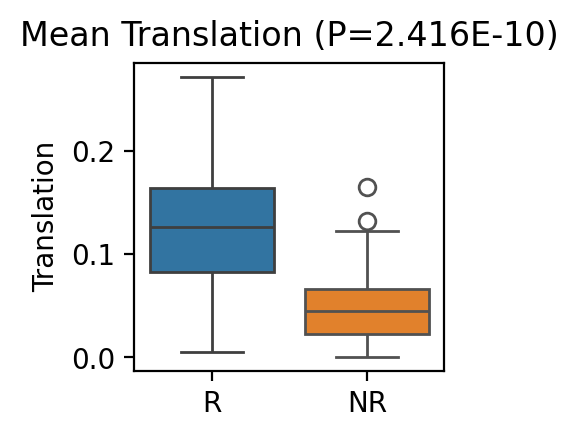

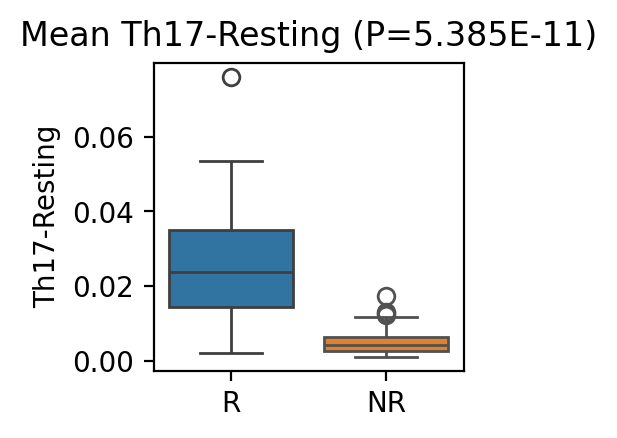

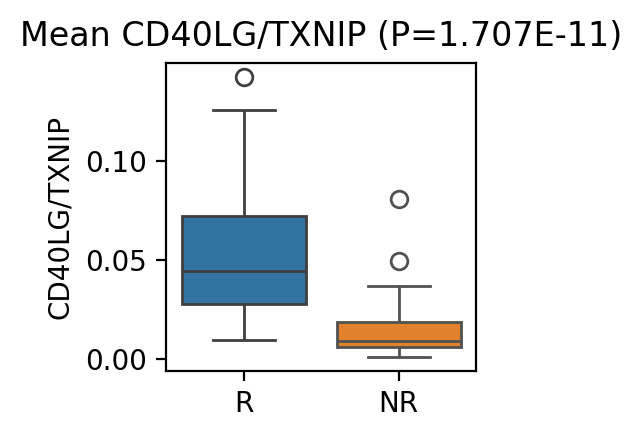

In [372]:
for g in res_t[res_t['pval']<0.05].sort_values('t').index:

    fig, ax = plt.subplots(dpi = 200, figsize = (2, 2))
    sns.boxplot(x = 0, y = high[g])
    sns.boxplot(x = 1, y = low[g])
    ax.set_xticklabels(['R', 'NR'])
    # ax.text(0.5, 1, s = 'P=%.4f' %p, transform = ax.transAxes, ha = 'center')
    ax.set_title('Mean ' + g + ' (P=%.3E)' % res_t.loc[g, 'pval'])